# Shakespeare Data Wrangling and Text Analysis

## Overview

This notebook focuses on cleaning and preparing the Shakespeare word frequency dataset generated using a Hadoop MapReduce WordCount job. The original WordCount output contains raw word counts extracted from Shakespeare's text corpus. While this output provides valuable information, it also includes common stop words, inconsistent capitalization, punctuation artifacts, and other issues that can reduce the quality of subsequent analysis.

The purpose of this notebook is to perform data wrangling and preprocessing to transform the raw WordCount output into a clean, analysis-ready dataset. After cleaning, the dataset will provide a more meaningful representation of Shakespeare's vocabulary and allow for more accurate analysis of word frequency patterns.

## Project Goal

The goal of this notebook is to clean and normalize the Hadoop WordCount output by removing noise and standardizing the text data. This process will improve data quality and prepare the dataset for exploratory analysis and visualization. The final result will be a cleaned word frequency table that highlights the most meaningful and frequently used words within Shakespeare's works.

## Data Wrangling Process

The following steps will be performed:

1. **Load the Hadoop WordCount Output**
   - Import the WordCount results into a Pandas DataFrame.
   - Verify the structure and data types of the dataset.

2. **Inspect the Raw Data**
   - Review sample records.
   - Identify inconsistencies such as punctuation, capitalization differences, and invalid entries.

3. **Normalize the Text**
   - Convert all words to lowercase.
   - Remove punctuation and non-alphabetic characters.
   - Standardize the format of all text entries.

4. **Remove Invalid Records**
   - Remove empty strings and other non-meaningful values created during the cleaning process.

5. **Remove Stop Words**
   - Eliminate common English stop words such as "the," "and," "of," and "to."
   - Retain only words that contribute meaningful analytical value.

6. **Recalculate Word Frequencies**
   - Group identical words created through normalization.
   - Sum their counts to produce accurate frequency totals.

7. **Analyze the Cleaned Dataset**
   - Identify the most frequently occurring words.
   - Compare the cleaned results with the original output.
   - Prepare the data for visualization and further analysis.

## Expected Outcome

Upon completion of the data wrangling process, the dataset will consist of normalized words and their corresponding frequencies. Common stop words and formatting inconsistencies will be removed, resulting in a cleaner and more interpretable dataset suitable for text analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load Shakespeare WordCount Text File
shakespeare_df = pd.read_csv(
    "/Users/tcbailey/Documents/imse785/projects/project1/outputs/shakespeare_wordcount.txt",
    sep=r"\s+",
    header=None,
    names=["word", "count"]
)
print(shakespeare_df.shape)
print(shakespeare_df.dtypes)

shakespeare_df.head()

(73036, 2)
word       str
count    int64
dtype: object


,word,count
0,&C,3
1,&c.,40
2,&c.',2
3,"&c.,",4
4,&c],23


In [12]:
# Clean and normalize the word counts
shakespeare_df["word"] = shakespeare_df["word"].str.lower()
shakespeare_df["word"] = shakespeare_df["word"].str.replace(r"[^a-z']", '', regex=True)

shakespeare_df.head()

,word,count
0,c,3
1,c,40
2,c,2
3,c,4
4,c,23


In [24]:
pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [nltk]3/4 [nltk]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
import nltk
from nltk.corpus import stopwords

In [28]:
nltk.download("stopwords")

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


False

In [33]:
# Remove stop words
stop_words = set(ENGLISH_STOP_WORDS)
shakespeare_df = shakespeare_df[~shakespeare_df["word"].str.lower().isin(stop_words)]

shakespeare_df_clean = (
    shakespeare_df.groupby("word", as_index=False)["count"]
      .sum()
      .sort_values("count", ascending=False)
)

shakespeare_df_clean.head(20)

,word,count
25671,thou,5783
25844,thy,4272
22665,shall,3724
25528,thee,3378
14949,lord,3355
13963,king,3317
23186,sir,3019
11017,good,2911
17277,o,2696
4800,come,2595


In [60]:
# Looking for Top 10 Nouns manually
shakespeare_df_clean.head(50)

,word,count
25671,thou,5783
25844,thy,4272
22665,shall,3724
25528,thee,3378
14949,lord,3355
13963,king,3317
23186,sir,3019
11017,good,2911
17277,o,2696
4800,come,2595


In [16]:
data = {
    "word": [
        "lord", "king", "sir", "love", "man", "duke", "time", "heart", "queen", "lady"
    ],
    "count": [
        3355, 3317, 3019, 2197, 1874, 1167, 1104, 1050, 1002, 983
    ]
}
top_nouns_df = pd.DataFrame(data)

print(top_nouns_df)

    word  count
0   lord   3355
1   king   3317
2    sir   3019
3   love   2197
4    man   1874
5   duke   1167
6   time   1104
7  heart   1050
8  queen   1002
9   lady    983


In [17]:
# Sort just in case
top_nouns_df = top_nouns_df.sort_values(by="count", ascending=False)

# Calculate cumulative percentage
top_nouns_df["cum_pct"] = (
    top_nouns_df["count"].cumsum() / top_nouns_df["count"].sum()
) * 100

print(top_nouns_df)

    word  count     cum_pct
0   lord   3355   17.594923
1   king   3317   34.990560
2    sir   3019   50.823369
3   love   2197   62.345291
4    man   1874   72.173275
5   duke   1167   78.293476
6   time   1104   84.083281
7  heart   1050   89.589889
8  queen   1002   94.844766
9   lady    983  100.000000


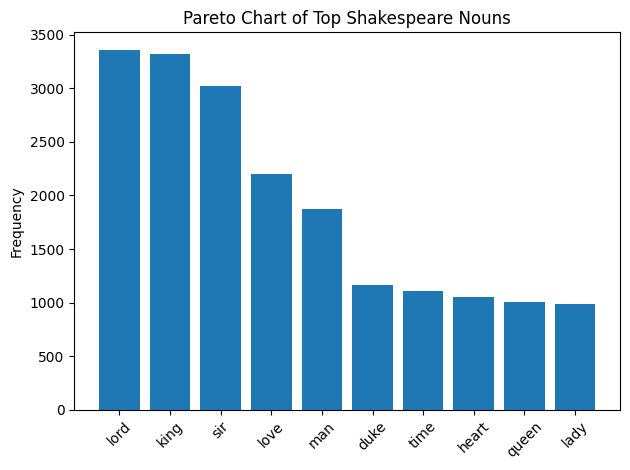

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# Bar chart (counts)
ax.bar(top_nouns_df["word"], top_nouns_df["count"])
ax.set_ylabel("Frequency")

plt.title("Pareto Chart of Top Shakespeare Nouns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()